## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>5 - Graph Problems</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

---

## Exercise 5.1

Solve the problem of point-feature cartographic label placement [50] as a maximum independent set of vertices problem, using the dataset [d25_01.dat](data/d25_01.dat).

[50] G. M. Ribeiro and L. A. N. Lorena, “Lagrangean relaxation with clusters for point-feature cartographic label placement problems,” Computers & Operations Research, vol. 35, no. 7, pp. 2129–2140, 2008, doi: 10.1016/j.cor.2006.10.013.

Maximum independent set (S) with 24 vertices:
2 8 12 15 19 23 28 32 34 
43 45 49 53 58 64 67 72 76 
85 91 94 99 

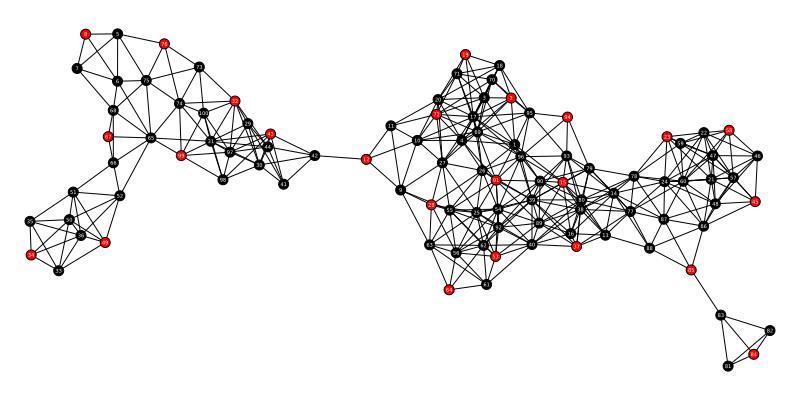

In [ ]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package
using Karnak # Graphs Visualization package
using Colors # Colors package

# Load utility function for plotting
include("utils/misp_utils.jl")

# Function to load dataset from a file
function load_dataset(file_path)
    # Open the file for reading
    f = open(file_path, "r")

    # Read the first line to get the number of points
    points = parse(Int, readline(f))
    
    # Read the next line to get the total of label positions
    positions = parse(Int, readline(f))
    
    # Calculate the total of labels
    labels = points * positions

    # Create a graph with the specified number of labels
    graph = Graphs.Graph(labels)

    # Vertex id
    vertex_id = 1

    # Read the next line to get the edge list
    while !eof(f)

        # Read the next vertex degree
        _ = parse(Int, readline(f))

        # Read the neighbors of the vertex
        neighbors = split(strip(readline(f)),' ')

        # Add edges to the graph for each neighbor
        for v in neighbors
            Graphs.add_edge!(graph, vertex_id, parse(Int, v))
        end

        # Increment the vertex id
        vertex_id += 1
    end

    close(f) # Close the file after reading
    
    return graph    
end

# Function to solve the Maximum Independent Set Problem (MISP)
function solve_misp(file_path)
    # Load the graph from the file
    graph = load_dataset(file_path)
    
    # Total of vertices
    n = Graphs.nv(graph)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n], Bin)

    # Objective function: maximize the total of selected vertices
    @objective(model, Max, sum(x))

    # Independence constraint
    @constraint(model, [i = 1:n, j = 1:n; Graphs.has_edge(graph, i, j)], x[i] + x[j] <= 1)

    # Run the solver
    JuMP.optimize!(model)

    # Independent set S
    S = findall(JuMP.value.(x) .>= 0.5)

    # Print solution
    println("Maximum independent set (S) with $(length(S)) vertices:")

    # Print 10 vertices per line
    for i in 1:length(S)
        i % 10 == 0 ? println() : print(S[i], " ")
    end

    # Plot solution
    plot_solution(graph, S)
end

# Example usage
solve_misp("data/d25_01.dat")

---

## Exercise 5.2

The director of a museum must decide how many guards should be employed to control its rooms. Each guard can guard the room in which he is stationed and adjacent ones through the doors between the rooms. Formulate an integer linear programming problem to give the minimum the number of guards so that all rooms are guarded (Vertex Covering Problem). Solve it for the map displayed in the following figure.

![Museum map for the vertex covering problem.](images/Chapter5-exercise2A.png)

#### Solution

The first step to solve this problem is to map each museum room to a number so that a graph could be constructed. Each room will be a vertex of the graph and the edges are placed for pairs of vertices that represent rooms with a door between them.

![Museum map with numbered rooms.](images/Chapter5-exercise2B.png)

Now we represent the museum as a graph, and the problem of finding the minimum number of guards is equivalent to finding the minimum vertex cover of the graph.

![Graph representation of the museum.](images/Chapter5-exercise2C.png)

The following code solves the problem as a Vertex Covering Problem. The obtained vertex cover set 𝐶 is presented in red. The manager should employe |𝐶| = 6 guards so that all rooms are guarded.

Vertex Cover set (C): [3, 5, 6, 8, 10, 11]


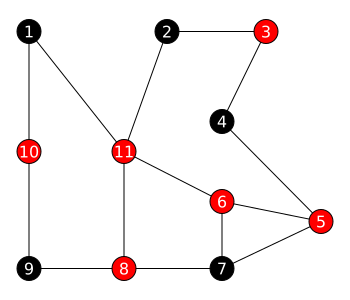

In [1]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/vcp_utils.jl")

# Function to solve the Vertex Covering Problem (VCP)
function solve_vcp(graph, positions; plot_graph_solution = false)
    # Total of vertices
    n = Graphs.nv(graph)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n], Bin)

    # Objective function: minimize the total of selected vertices
    @objective(model, Min, sum(x))

    # Vertex Cover constraint
    @constraint(model, [i = 1:n, j = 1:n; Graphs.has_edge(graph, i, j)], x[i] + x[j] >= 1)

    # Run the solver
    JuMP.optimize!(model)

    # Vertex Cover C
    C = findall(JuMP.value.(x) .>= 0.5)

    # Print solution
    println("Vertex Cover set (C): $C")

    # Plot graph solution if requested
    if plot_graph_solution
        fig = plot_solution(graph, positions, C)
        display(fig)
    end
end

# Create graph
graph = Graphs.Graph(11)

# Edges
edges = [(1,10), (1,11), (2,3), (2,11), 
         (3,4), (4,5), (5,6), (5,7), 
         (6,7), (6,11), (7,8), (8,9), 
         (8,11), (9,10)]

# Add edges
for (u, v) in edges
    Graphs.add_edge!(graph, u, v)
end

# Manually define the vertices positions for the layout
positions = [Point(0,0), Point(138,0),
             Point(237,0), Point(193,90),
             Point(292,190), Point(193,170),
             Point(193,237), Point(95,237),
             Point(0,237), Point(0,120),
             Point(95,120)]

# Solve the Vertex Covering Problem
solve_vcp(graph, positions, plot_graph_solution = true)

---

## Exercise 5.3

The following figure presents a map with 34 districts of São José dos Campos, Brazil. Formulate and solve the Graph Coloring Problem to color the map with the minimum number of colors such that no two adjacent districts share the same color. Use the dataset [districts.csv](data/districts.csv) as input.

![Map instance for the Graph Coloring Problem.](images/Chapter5-exercise3A.png)

#### Solution

The first step to solve this problem is to map each district to a number so that a graph could be constructed (Figure E.5). Each district will be a vertex of the graph and the edges are placed for pairs of vertices that represent districts with a common border.

![Graph representation of the districts.](images/Chapter5-exercise3B.png)

Now, based on the graph, we can solve the problem as a Graph Coloring Problem. In the following code, the obtained vertex coloring is presented. The minimum number of colors required to color the graph is 4, so the city council should use 4 different colors to paint the districts.

Chromatic number: 4
Group 1: [2, 4, 9, 18, 21, 27, 28, 29, 31]
Group 2: [6, 7, 10, 16, 19, 26, 30]
Group 3: [3, 8, 12, 14, 17, 20, 22, 24, 25]
Group 4: [1, 5, 11, 13, 15, 23, 32, 33, 34]


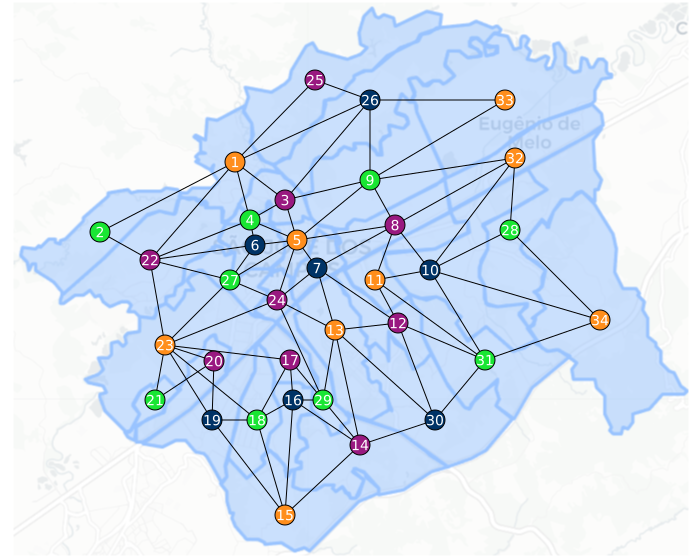

Python: <folium.folium.Map object at 0x7f60e7dde270>

ERROR 1: PROJ: proj_create_from_database: Open of /home/luiz/book-codes/.CondaPkg/.pixi/envs/default/share/proj failed


In [ ]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/gcp_utils.jl")

# Function to solve the Graph Coloring Problem (GCP)
function solve_gcp(graph_file, map_file, map_background_file; plot_graph_solution = true, plot_map_solution = true)
    # Create graph
    graph = Graphs.loadgraph(graph_file)
    
    # Total of vertices
    n = Graphs.nv(graph)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n, 1:n], Bin)
    @variable(model, y[1:n], Bin)

    # Objective function: minimize the total of selected colors
    @objective(model, Min, sum(y))

    # Each vertex must be assigned to exactly one color
    @constraint(model, [u = 1:n], sum(x[u, :]) == 1)

    # If a vertex uses color c, then color c is active
    @constraint(model, [u = 1:n, c = 1:n], x[u, c] <= y[c])

    # No two adjacent vertices share the same color
    @constraint(model,
                [u = 1:n, v = u+1:n, c = 1:n; Graphs.has_edge(graph, u, v)],
                x[u, c] + x[v, c] <= 1)

    # Run the solver
    JuMP.optimize!(model)
    
    if JuMP.termination_status(model) != JuMP.OPTIMAL
        error("No optimal solution found.")
    end

    # Chromatic number
    chromatic_number = Int(round(JuMP.objective_value(model)))
    println("Chromatic number: $chromatic_number")

    # Extract the optimal color assignments
    x_opt = JuMP.value.(x)
    y_opt = JuMP.value.(y)

    # Create solution array
    solution = zeros(Int, n)
    selected_colors = findall(y_opt .>= 0.5)
    for (id, pos) in enumerate(selected_colors)
        ids = findall(x_opt[:, pos] .>= 0.5)
        solution[ids] .= id
        println("Group $id: $ids")
    end

    # Plot graph solution if requested
    if plot_graph_solution
        fig = plot_solution_graph(graph, map_background_file, solution)
        display(fig)
    end

    # Plotting map solution if requested
    if plot_map_solution
        fmap = plot_solution_map(map_file, solution)
        display(fmap)
    end
end

# Example usage
solve_gcp("data/districts.csv", "data/districts.geojson", "images/districts.png")

---

## Exercise 5.4

The circuit board in the following figure has 48 components. Formulate and solve the Graph Partitioning Problem into 3 balanced groups, while minimizing the number cut edges. Use the graph dataset [circuit.csv](data/circuit.csv) as input, which contains the list of components and their connections.

![Circuit board instance for the Graph Partitioning Problem.](images/Chapter5-exercise4A.png)

#### Solution

The first step to solve this problem as the Graph Partitioning Problem is representing the
graph as shown in the following figure.

![Graph representation of the problem.](images/Chapter5-exercise4B.png)

The following code solves the problem as a Graph Partitioning Problem. The obtained partition presented, and the graph is partitioned into 3 balanced groups, with 11 cut edges between groups.

Edge cuts total: 11

Edge cuts:
(1, 10) (9, 15) (13, 20) (18, 24) (19, 24) (23, 28) (28, 32) (29, 33) 
(32, 38) (36, 41) (37, 42) 

Partitions:
Partition 1 (16 components): [1, 2, 3, 7, 8, 9, 12, 13, 17, 18, 22, 23, 27, 32, 33, 37]
Partition 2 (16 components): [4, 5, 6, 10, 11, 14, 15, 16, 19, 20, 21, 25, 26, 30, 31, 36]
Partition 3 (16 components): [24, 28, 29, 34, 35, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]


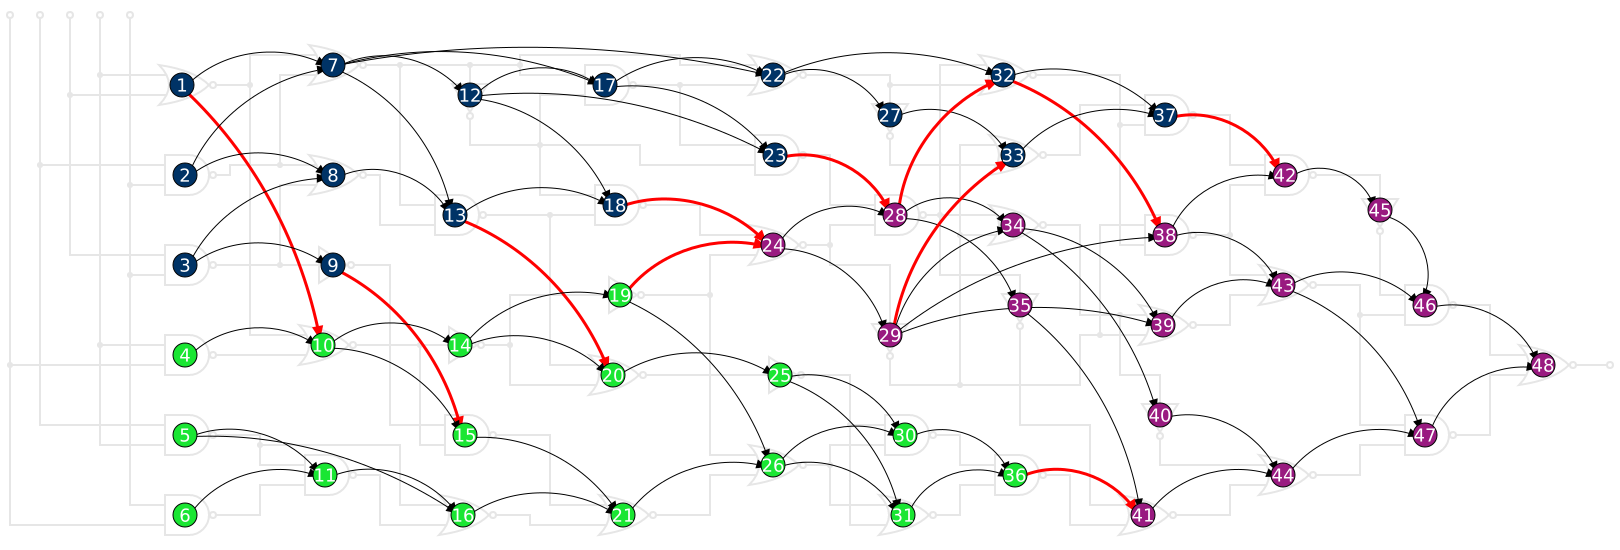

In [1]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/gpp_utils.jl")

# Function to solve the Graph Partitioning Problem (GPP)
function solve_gpp(graph_file; k = 2, circuit_background = nothing, plot_graph_solution = true)
    # Load graph from file
    graph = Graphs.loadgraph(graph_file)
    
    # Total of vertices
    n = Graphs.nv(graph)

    # Total of edges
    m = Graphs.ne(graph)

    # Define lower and upper size limits for each partition
    L = floor(Int, n / k)
    U = ceil(Int, n / k)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n, 1:k], Bin)  # x[u,i] = 1 if vertex u is in partition i
    @variable(model, y[1:m], Bin)       # y[e] = 1 if edge e is a cut edge
    
    # Objective: minimize number of cut edges
    @objective(model, Min, sum(y))
        
    # Each vertex must be assigned to exactly one partition
    @constraint(model, [u in 1:n], sum(x[u, p] for p in 1:k) == 1)

    # Partition balance constraint
    @constraint(model, [p in 1:k], sum(x[u, p] for u in 1:n) >= L)
    @constraint(model, [p in 1:k], sum(x[u, p] for u in 1:n) <= U)

    # Define y[e] = 1 if edge connects different partitions
    for (e_id, e) in enumerate(Graphs.edges(graph))
        u, v = Graphs.src(e), Graphs.dst(e)
        for p in 1:k
            @constraint(model, y[e_id] >= x[u, p] - x[v, p])
            @constraint(model, y[e_id] >= x[v, p] - x[u, p])
        end
    end

    # Run the solver
    JuMP.optimize!(model)

    # Print solution
    println("Edge cuts total: ", round(Int, JuMP.objective_value(model)))
    
    # Get partitions
    partitions = [findall(JuMP.value.(x[:,id]) .> 0.5) for id in 1:k]

    # Get cut edges
    cut_edges = []
    for (e_id, e) in enumerate(Graphs.edges(graph))
        if JuMP.value(y[e_id]) > 0.5
            push!(cut_edges, (Graphs.src(e), Graphs.dst(e)))
        end
    end

    # Print results
    println("\nEdge cuts:")
    for (id, cut_edge) in enumerate(cut_edges)
        print("$cut_edge ")
        if id % 8 == 0
            println()
        end
    end

    println("\n\nPartitions:")
    for (id, partition) in enumerate(partitions)
        println("Partition $id ($(length(partition)) components): ", partition)
    end

    # Plot graph solution if requested
    if plot_graph_solution
        fig = plot_solution(graph, partitions, y, k; circuit_background = circuit_background)
        display(fig)
    end
end

# Solve the Graph Partitioning Problem
solve_gpp("data/circuit.csv", k = 3, circuit_background = "images/circuit_background.png")

---

## Exercise 5.5

Formulate and solve the Clique Partitioning Problem for the graph in the following figure, which represents a social network of 34 individuals. The goal is to partition the graph into communities that maximize modularity. Use the dataset [karate.csv](data/karate.csv) as input, which contains the list of individuals and their connections.

![ Social network instance for the Clique Partitioning Problem.](images/Chapter5-exercise5.png)

Modularity: 0.41978961209730403
Partition:
Cluster 1: 1 2 3 4 8 12 13 14 18 20 22 
Cluster 2: 5 6 7 11 17 
Cluster 3: 9 10 15 16 19 21 23 27 30 31 33 34 
Cluster 4: 24 25 26 28 29 32 


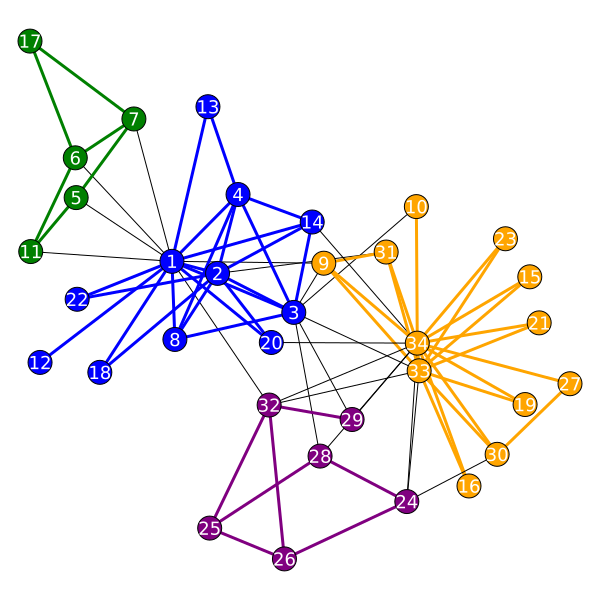

In [1]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/cpp_utils.jl")

# Function to solve the Clique Partitioning Problem (CPP)
function solve_cpp(graph_file)
    # Load the graph from the file
    graph = Graphs.loadgraph(graph_file)

    # Get number of vertices and edges
    n = Graphs.nv(graph)
    m = Graphs.ne(graph)

    # Auxiliary variables to simplify notation
    V = 1:n

    # Modularity matrix Q
    Q = zeros(n,n)
    for u in V
        for v in V
            du = Graphs.degree(graph, u)
            dv = Graphs.degree(graph, v)
            a_ij = Graphs.has_edge(graph, u, v) ? 1 : 0
            Q[u,v] = a_ij/(2*m) - (du * dv) / (4*m^2)
        end
    end

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[u in V, v in V], Bin)

    # Objective: maximize the weight of the selected edges
    @objective(model, Max, sum(Q[u,v] * x[u,v] for u in V for v in V))

    # Transitive Constraints: ensure that the selected edges form a valid partition
    for u in V
        for v in V
            for w in V
                @constraint(model,  x[u,v] + x[v,w] - x[u,w] <= 1)
                @constraint(model,  x[u,v] - x[v,w] + x[u,w] <= 1)
                @constraint(model, -x[u,v] + x[v,w] + x[u,w] <= 1)
            end
        end
    end

    # Run the solver
    JuMP.optimize!(model)

    # Get the objective (modularity)
    modularity = JuMP.objective_value(model)
    println("Modularity: ", modularity)

    # Extract the optimal partition
    println("Partition:")
    partition = zeros(Int64, n)
    partition_id = 1
    for u in V
        # If vertex u is not yet assigned to a partition
        if partition[u] == 0
            print("Cluster $partition_id: ")
            for v in V
                # If vertex v is in the same partition as u
                if JuMP.value(x[u,v]) > 0.5
                    # Assign both u and v to the same partition
                    partition[v] = partition_id
                    print("$v ")
                end
            end
            print("\n")
            partition_id += 1
        end
    end
    # Plot solution
    plot_solution(graph, partition)
end

# Example usage
solve_cpp("data/karate.csv")